In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH = 'sawo.png'

def clean_mask(mask, min_area_ratio=0.01):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled = np.zeros_like(mask)
    img_area = mask.shape[0] * mask.shape[1]
    for cnt in contours:
        if cv2.contourArea(cnt) > img_area * min_area_ratio:
            cv2.drawContours(filled, [cnt], -1, 255, -1)
    return filled

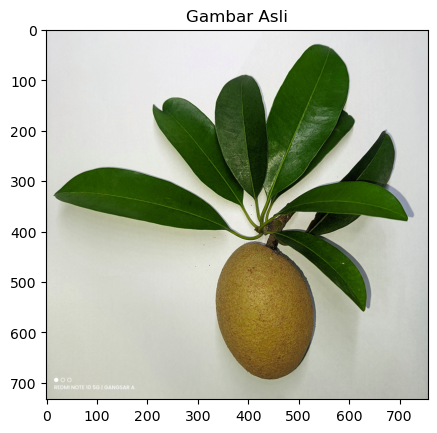

In [2]:
img = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

plt.imshow(img_rgb)
plt.title('Gambar Asli')
plt.show()

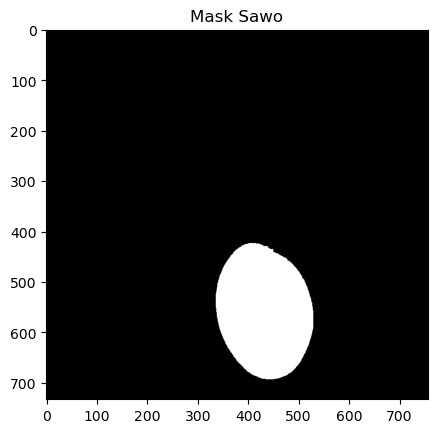

In [3]:
lower_sawo = np.array([10, 100, 60])
upper_sawo = np.array([30, 255, 220])
mask_sawo = cv2.inRange(hsv, lower_sawo, upper_sawo)

kernel = np.ones((5, 5), np.uint8)
mask_sawo = cv2.morphologyEx(mask_sawo, cv2.MORPH_CLOSE, kernel)
mask_sawo = cv2.morphologyEx(mask_sawo, cv2.MORPH_OPEN, kernel)
mask_sawo = clean_mask(mask_sawo)

plt.imshow(mask_sawo, cmap='gray')
plt.title('Mask Sawo')
plt.show()

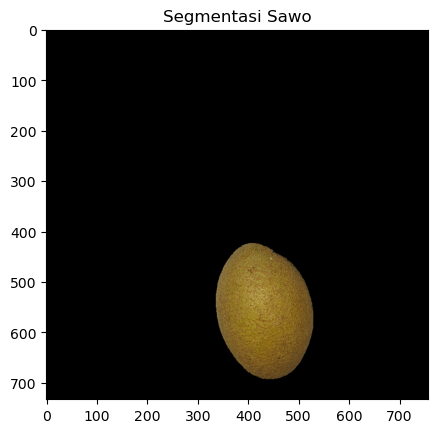

In [4]:
segmentasi_sawo = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_sawo)

plt.imshow(segmentasi_sawo)
plt.title('Segmentasi Sawo')
plt.show()

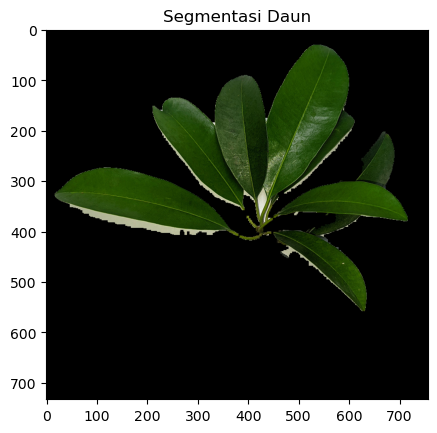

In [5]:
lower_green = np.array([30, 40, 30])
upper_green = np.array([90, 255, 255])
mask_daun = cv2.inRange(hsv, lower_green, upper_green)

mask_daun = cv2.morphologyEx(mask_daun, cv2.MORPH_CLOSE, kernel)
mask_daun = cv2.morphologyEx(mask_daun, cv2.MORPH_OPEN, kernel)
mask_daun = clean_mask(mask_daun, min_area_ratio=0.003)

segmentasi_daun = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_daun)

plt.imshow(segmentasi_daun)
plt.title('Segmentasi Daun')
plt.show()

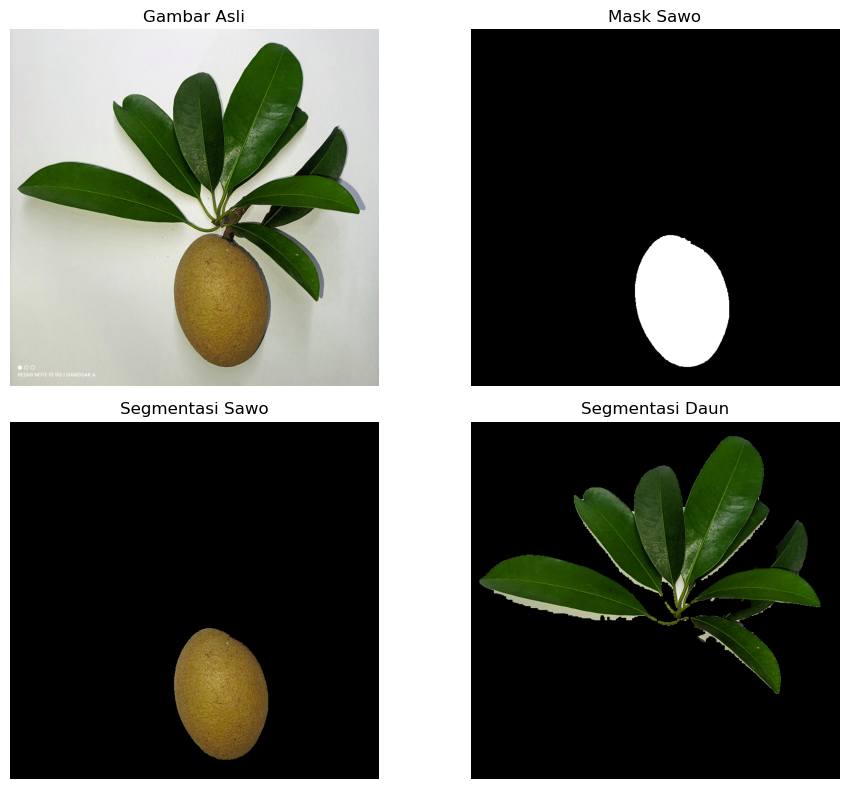

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0, 0].imshow(img_rgb)
axs[0, 0].set_title('Gambar Asli')

axs[0, 1].imshow(mask_sawo, cmap='gray')
axs[0, 1].set_title('Mask Sawo')

axs[1, 0].imshow(segmentasi_sawo)
axs[1, 0].set_title('Segmentasi Sawo')

axs[1, 1].imshow(segmentasi_daun)
axs[1, 1].set_title('Segmentasi Daun')

for ax in axs.flat:
    ax.axis('off')

plt.tight_layout()
plt.savefig('hasil_segmentasi2.png', dpi=150)
plt.show()